# Modeling nonlinear data

**Objectives** In this lesson, you will learn:
*  how to identify non-linear relationships in your data by visualizing it
*  how to fit a linear regression model as a baseline using scipy.stats.linregress
*  how to assess the quality of a fit using r_value, p_value, and std_err
*  how to define and use a Python function
*  how to use scipy.optimize.curve_fit to fit a logarithmic model
*  how to interpret popt (fitted parameters) and pcov (covariance matrix) from curve_fit



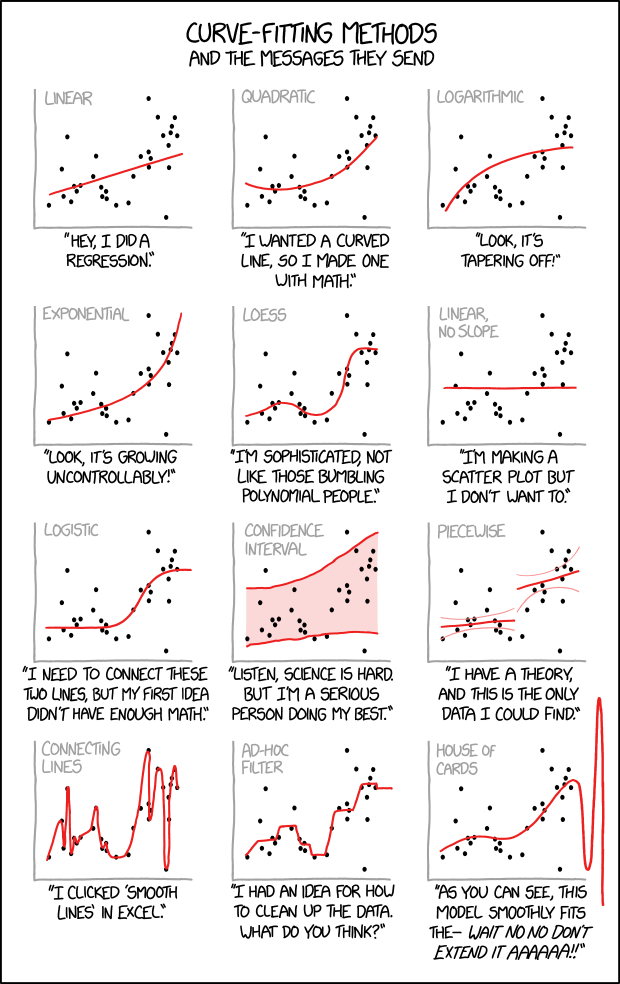

## Example Concrete Strength vs Curing Time for different curing methods
Today let's look at some nonlinear AE data!

Let's retrieve some data about the **strength of concrete** as a **function of curing time and curing method**.

**Curing plays an important role on strength development and durability of concrete.** Curing takes place immediately after concrete placing and finishing, and involves maintenance of desired moisture and temperature conditions, both at depth and near the surface, for extended periods of time. Properly cured concrete has an adequate amount of moisture for continued hydration and development of strength, volume stability, resistance to freezing and thawing, and abrasion and scaling resistance.

*   Here is the raw data from "*Effects of Curing Condition and Curing Period on the Compressive Strength Development of Plain Concrete*" by Akinwumi and Gbadamosi:

![](https://www.researchgate.net/profile/Isaac-Akinwumi/publication/264276085/figure/fig3/AS:296025886609410@1447589479356/Variation-of-compressive-strength-with-curing-period.png)

citation: https://www.cement.org/learn/concrete-technology/concrete-construction/curing-in-construction

## 1. Reading our data

In [ ]:
import pandas as pd # same method for importing as before
import requests

#import data
url = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/EZWuWeoRSOFIiF5ex0Lag6sBBJv4neyFltFHQNxAjxefXw?e=RGo6U4&download=1'
r = requests.get(url)
r.status_code
with open('data.csv', 'w') as fid:
    fid.write(r.text)


data = pd.read_csv('data.csv')

data

## 2. Cleaning our data
So it looks like **there are some nans** in there so let's try cleaning those out first.

In [ ]:
# Dropping NaN values
data_clean = data.dropna()

# Get the number of rows after dropping NaN values
original_size = len(data)
new_size = len(data_clean)

# Calculate the number of rows removed
rows_removed = original_size - new_size

print("Number of rows removed:", rows_removed)

## 3. Visualizing our data
Now that our data is cleaned, let's start by **visualizing the data and looking for trends**. So let's start by making a *scatter plot*.

#### **Question?**

What is the dependent and independent variable in the dataset above?


For every column in your dataframe make a **scatter plot** showing the relationship between the **independent variable** and the **dependent variables**. Make sure you have a legend for your chart.


In [ ]:
# plot the data in the dataframe above: curing time vs concrete strength
import numpy as np
from matplotlib import pyplot as plt

x = data_clean['Curing time (days)']
columns = data_clean.columns
print(columns)

# Plot each dependent variable against the independent variable (x)
fig, ax = plt.subplots()
for col in data_clean.columns[1:]:  # skip the first column!
    y = data_clean[col]
    ax.scatter(x, y, label=col)

ax.set_xlabel('Curing time (days)')
ax.set_ylabel('Dependent Variables')
ax.set_title('Scatter Plot of Dependent Variables vs Curing time (days)')
ax.legend()

## 4. Prediction with Linear Regression

What if I want to check the corresponding value for our dependent variables would be for a curing time that I didn't measure?

That is when we can use a line of best fit to make predictions.

### 4.1 Linear regression
Let's start by performing a linear regression on the first feature (lime water) using the **linregress() method from scipy.stats (library)**.


#### **Your Turn (Tuesday)**
Calculate the predicted y value for this linear regression. Then plot the linear regression and the scatter plot for your data on the same axes. Take a screenshot of your code and final plot.

In [ ]:
# your turn!

### 4.2 Checking Accuracy

This **line doesnt fit our data very well**, but can we quantify how well it does / does not fit our data?

We can use the *r_value*, *p_value*, and *std_err* to make judgments about how well this fits.

In [ ]:
print(r_value)
print(p_value)
print(std_err)


## The values **r_value, p_value, and std_err are outputs from the linear regression analysis**.



They provide information about the quality of the linear regression model and the statistical significance of the relationship between the independent variable - Curing time (days) - and the dependent variable - Concrete Strength(N/mm2) - for lime water method.

Here's what each value represents:

* r_value: This is the correlation coefficient, also known as the Pearson correlation coefficient. It measures the strength and direction of the linear relationship between the two variables. The value ranges from -1 to 1, where:

  * 1 indicates a perfect positive linear relationship,
  * -1 indicates a perfect negative linear relationship,
  * 0 indicates no linear relationship.

In our case, **r_value is approximately 0.907**, indicating a **strong positive linear** relationship between curing time and lime water strength.

* p_value: This is the value associated with the null hypothesis, which states that the correlation coefficient (r_value) is zero, implying no linear relationship between the variables. **A small p-value (typically less than 0.05) indicates that the observed correlation is statistically significant**, meaning it is unlikely to have occurred by chance.

In our case, the p-value is extremely small (7.11 × 10⁻¹¹ in scientific notation), suggesting that the observed correlation is indeed statistically significant.

* std_err: This represents the standard error of the estimate, which measures the average deviation of the observed values from the regression line. It provides information about the accuracy of the regression model's predictions. A **smaller standard error indicates a more accurate model**.

In our case, std_err is approximately 0.0154, suggesting that the model's predictions have a relatively low average deviation from the actual values.

## 5. Nonlinear curve-fitting methods
But could we do any better with a model that is **nonlinear**?

#### **Question?**
Do any of the examples below look like our data?

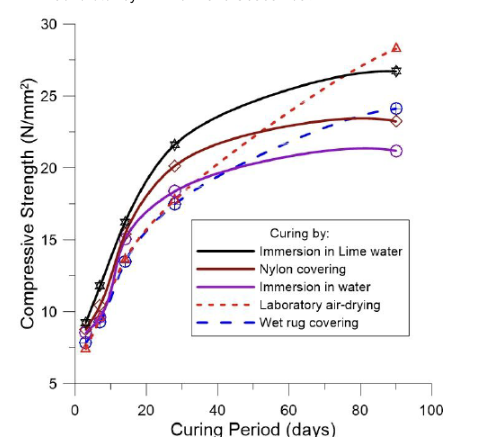

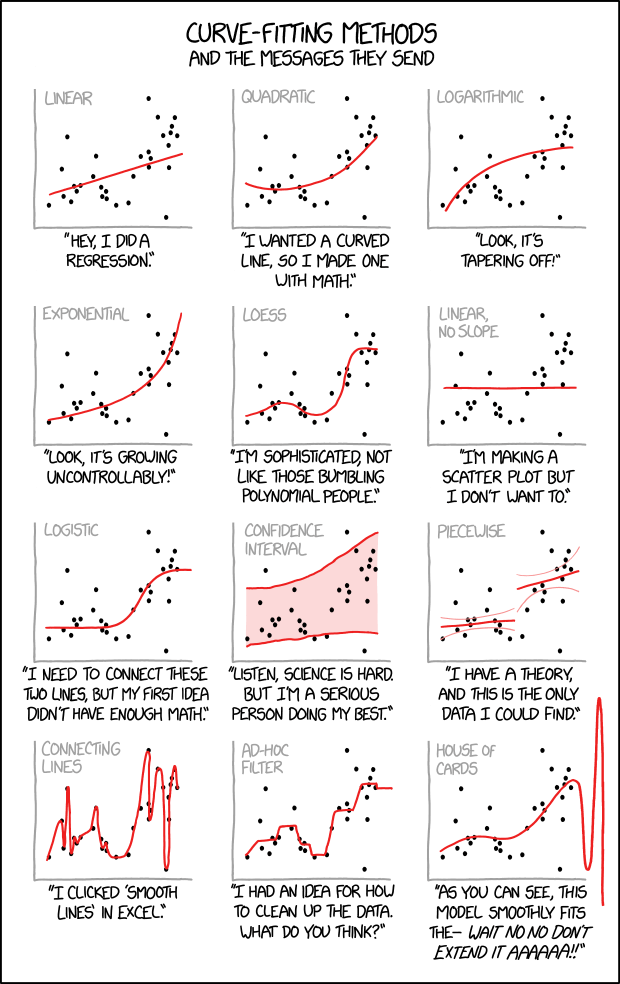

Log looks pretty good! So let's try to implement it!

We will use a new function called **curve_fit()** from **scipy.optimize library** to do this!

docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html

So let's look at the syntax for this:
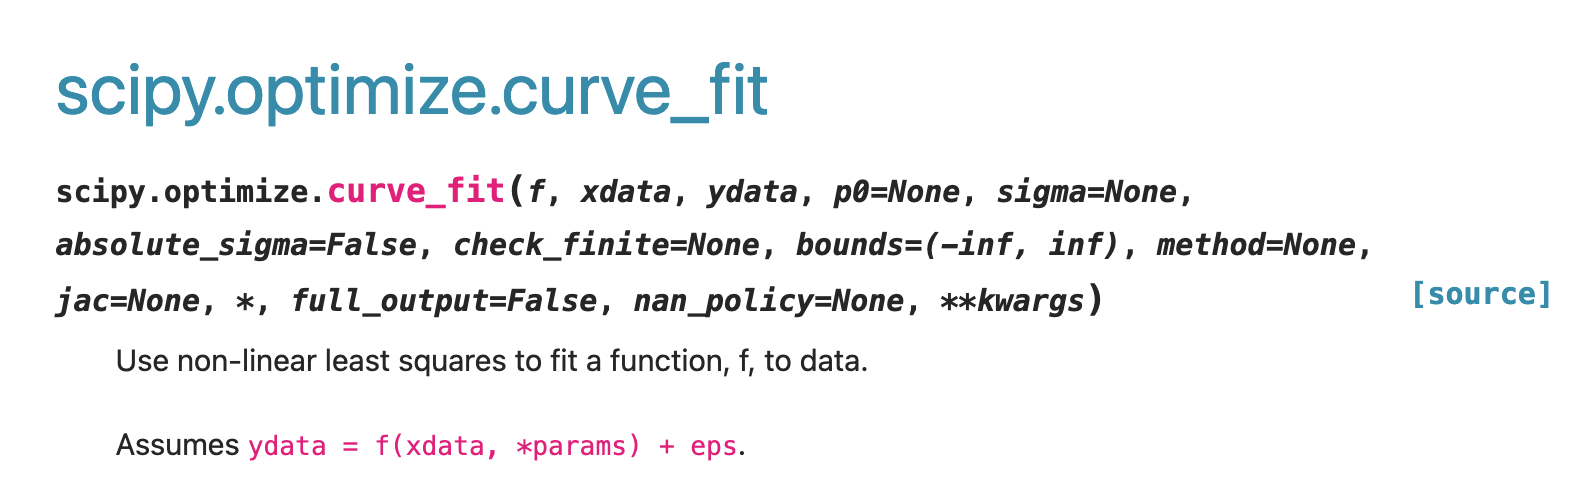

So this says that scipy takes in a function... what is that?

well to tackle complex problems like this, we often need to create our own custom tools. In Python, we do this by defining a function.



Let's take a quick detour to learn the basic syntax of creating a function!

## What is a Function?

A function is a block of organized, reusable code that is used to perform a single, related action. Functions provide better modularity for your application and a high degree of code reusing.

As you already know, Python gives you many built-in functions like print(), etc. but you can also create your own functions. These functions are called user-defined functions.

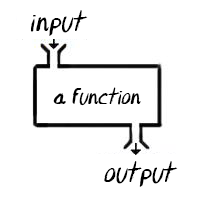



### Defining a Function
You can define functions to provide the required functionality. Here are simple rules to define a function in Python.

1. Function blocks begin with the keyword def followed by the function name and parentheses ( ( ) ).

2. Any input parameters or arguments should be placed within these parentheses. You can also define parameters inside these parentheses.

3. The first statement of a function can be an optional statement - the documentation string of the function or docstring.

4. The code block within every function starts with a colon (:) and is indented.

5. The statement return [expression] exits a function, optionally passing back an expression to the caller. A return statement with no arguments is the same as return None.

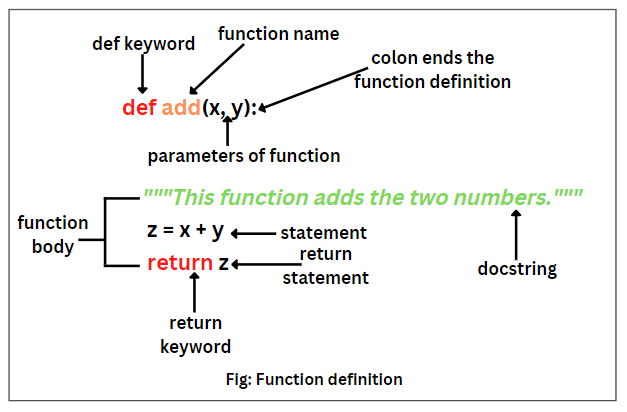



citation: https://www.tutorialspoint.com/python/python_functions.htm#:~:text=A%20function%20is%20a%20block,perform%20a%20single%2C%20related%20action.&text=As%20you%20already%20know%2C%20Python,are%20called%20user%2Ddefined%20functions.

citation: https://www.scientecheasy.com/2022/11/functions-in-python.html/




```
# this is just syntax
def functionname( parameters ): #function name can change, parameters can also change
   "function_docstring" #optional
   function_suite #something that is happening to our parameters
   return [expression] #what do we want it to tell us after the function runs

#By default, parameters have a positional behavior and you need to inform them
# in the same order that they were defined.
```



### example
Here's a very basic example of a Python function that calculates the area of a rectangle:

In [ ]:
def calculate_rectangle_area(length, width):
    """
    Calculate the area of a rectangle given its length and width.

    Parameters:
    length (float): The length of the rectangle.
    width (float): The width of the rectangle.

    Returns:
    float: The area of the rectangle.
    """
    area = length * width
    return area

# Example usage:
rectangle_length = 5
rectangle_width = 3
area_of_rectangle = calculate_rectangle_area(rectangle_length, rectangle_width)
print("Area of the rectangle:", area_of_rectangle)


In this example:

* We define a function called calculate_rectangle_area that takes two parameters: length and width.
* Inside the function, we calculate the area of the rectangle by multiplying the length and width.
* We then return the calculated area.
* Finally, we call the function with example values for the length and width of a rectangle and print the result.

**Note we need to call the function for it to run!**

Okay, now that we have the basic recipe for how to build a function, let's create the specific ones we need to model our concrete data!

### 5.1 Testing Log regression

Let's use a logarithmic function as the function for the curve fit method :
https://www.geeksforgeeks.org/how-to-do-exponential-and-logarithmic-curve-fitting-in-python/


$y = a*ln(x) + b$

In [ ]:
# Define a nonlinear model (logarithmic) to fit to the data
def log_model(x, a, b):  # function to calculate y for our formula (log model)
    # Calculate the y value for the logarithmic function using the given parameters 'x', 'a' and 'b'
    y = a * np.log(x) + b
    return y

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# defining our data like normal
x = data_clean['Curing time (days)']
y = data_clean['Lime water (N/mm2)']

# Fit the nonlinear model to the data
popt, pcov = curve_fit(log_model, x, y)

In [ ]:
## Let's see **what the curve_fit function is returning to us**!

print('popt:\n',popt)
print('pcov:\n',pcov)

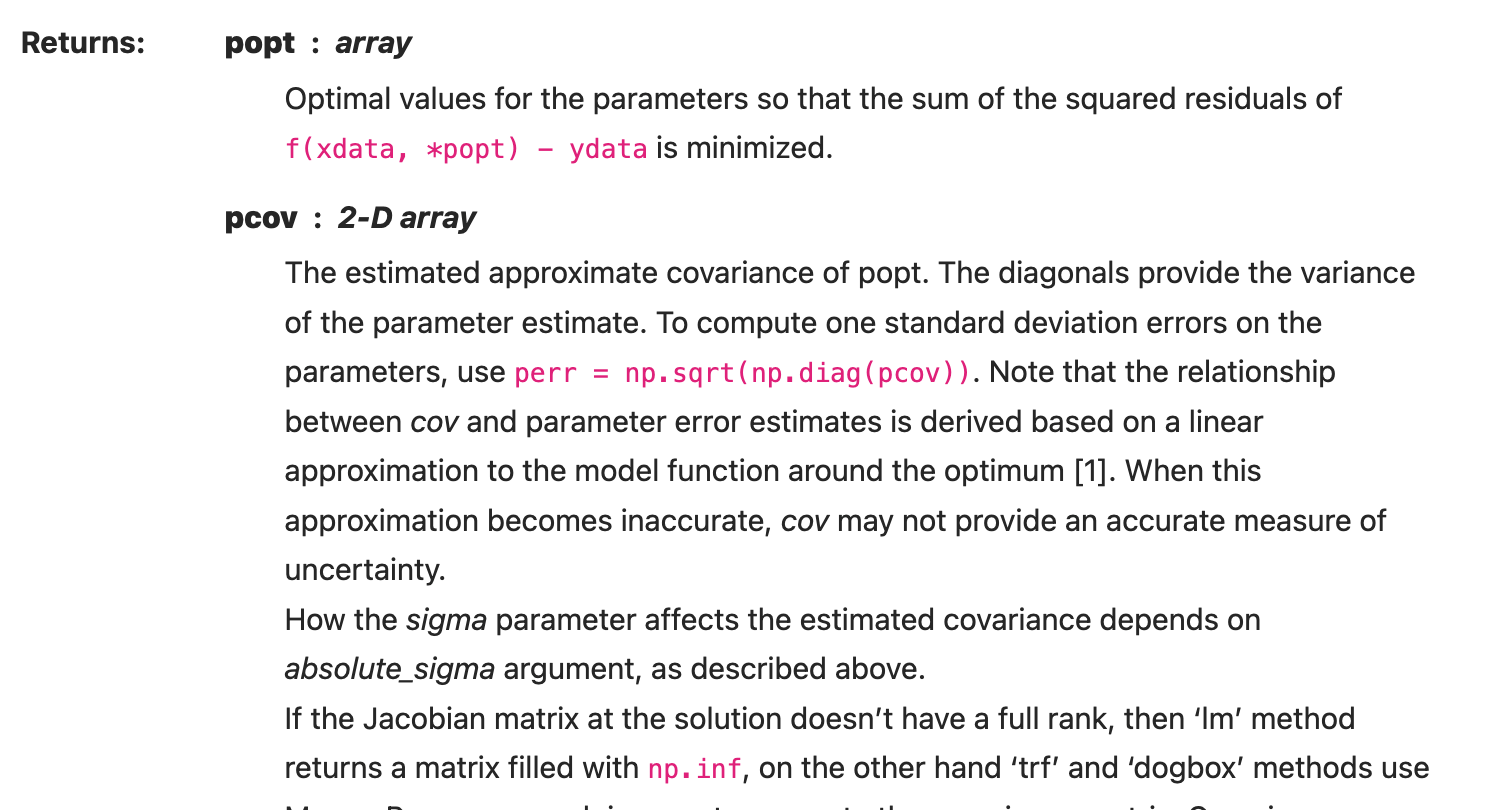



#### Parameter popt
**popt returns a list of the parameters/coefficients - function constants - we are trying to fit with our model**. So if we look at our model above, we said we were trying to fit 2 parameters, and we called them a and b in that order.

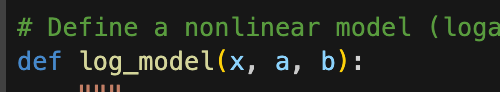

so this means

# a = popt[0]
# b = popt[1]

In [ ]:
a = popt[0]
b = popt[1]

In [ ]:
# and the equation would look like:
print('y = {} * log(x) + {}'.format(round(a, 2), round(b,2)))

### Visualizing the predicted values using curve_fit() with log

So let's **use the popt values to predicted y log values**, make a scatter plot of the original data, and then plot our new log based prediction on top of that

In [ ]:
# Predicting values using the log model with the coefficients from curve fit
predicted_y_log = log_model(x, popt[0], popt[1])

# Plot scatter plot
fig, ax = plt.subplots()
ax.scatter(x, y, label='Measured data')

# Plot nonlinear fit
ax.plot(x, predicted_y_log, color='red', label='Log fit')

ax.set_xlabel('Curing time (days)')
ax.set_ylabel('Concrete Strength (N/mm2)')
ax.set_title('Concrete Strength vs Curing time - Lime Water method')
ax.legend()
plt.show()

### 5.2 Checking model accuracy from curve_fit()

#### pcov parameter?
It is the covariance matrix

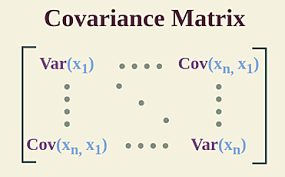

Where:

* The **diagonal** values represent the **variances** of the fitted parameters - in whichvariance is a measure of how spread out the values in a dataset are. It tells you how much the data deviates from the mean (average value).
* The **off-diagonal** values represent the **covariances** between pairs of parameters.


In [ ]:
# in our example:
print('pcov:\n',pcov)

# Covariance measures how two variables vary together

Covariance measures how two variables vary together.


*   Positive covariance: Both variables tend to increase or decrease together.
*   Negative covariance: When one variable increases, the other tends to decrease.
*   Near-zero covariance: The variables are mostly independent.

---
## 📋 Today's In-Class Assignment

**Your Turn (Tuesday) above is your in-class assignment for today. Submit it to Canvas before you leave.**

To submit:
1. Make sure your code in the cell above runs without errors (press Shift+Enter to run it)
2. Take a screenshot of your code and its output
3. Go to the module on Canvas that this lesson was part of and find today's in-class assignment, due at midnight
4. Upload your screenshot

*If you have multiple screenshots, combine them into a single PDF before uploading.*

**You only need to show that you tried; this is graded on effort, not perfection.**

---